# EDA of Fashion Dataset

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
DATASET_DIR = Path("/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset")

STYLES_CSV = DATASET_DIR / "styles.csv"
IMAGES_CSV = DATASET_DIR / "images.csv"
IMAGES_DIR = DATASET_DIR / "images"
STYLES_DIR = DATASET_DIR / "styles"

## 1. Structure of dataset

In [3]:
df = pd.read_csv(STYLES_CSV, on_bad_lines='skip')

print("shape:", df.shape)

shape: (44424, 10)


In [4]:
df.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44424 entries, 0 to 44423
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  44424 non-null  int64  
 1   gender              44424 non-null  object 
 2   masterCategory      44424 non-null  object 
 3   subCategory         44424 non-null  object 
 4   articleType         44424 non-null  object 
 5   baseColour          44409 non-null  object 
 6   season              44403 non-null  object 
 7   year                44423 non-null  float64
 8   usage               44107 non-null  object 
 9   productDisplayName  44417 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 3.4+ MB


In [6]:
columns = df.columns.tolist()
columns

['id',
 'gender',
 'masterCategory',
 'subCategory',
 'articleType',
 'baseColour',
 'season',
 'year',
 'usage',
 'productDisplayName']

In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,44424.0,NaN,NaN,NaN,29696.334301,17049.490518,1163.0,14768.75,28618.5,44683.25,60000.0
gender,44424,5,Men,22147,NaN,NaN,NaN,NaN,NaN,NaN,NaN
masterCategory,44424,7,Apparel,21397,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subCategory,44424,45,Topwear,15402,NaN,NaN,NaN,NaN,NaN,NaN,NaN
articleType,44424,143,Tshirts,7067,NaN,NaN,NaN,NaN,NaN,NaN,NaN
baseColour,44409,46,Black,9728,NaN,NaN,NaN,NaN,NaN,NaN,NaN
season,44403,4,Summer,21472,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,44423.0,NaN,NaN,NaN,2012.806497,2.12648,2007.0,2011.0,2012.0,2015.0,2019.0
usage,44107,8,Casual,34406,NaN,NaN,NaN,NaN,NaN,NaN,NaN
productDisplayName,44417,31121,Lucera Women Silver Earrings,82,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df.nunique().sort_values()

season                    4
gender                    5
masterCategory            7
usage                     8
year                     13
subCategory              45
baseColour               46
articleType             143
productDisplayName    31121
id                    44424
dtype: int64

In [9]:
df.dtypes

id                      int64
gender                 object
masterCategory         object
subCategory            object
articleType            object
baseColour             object
season                 object
year                  float64
usage                  object
productDisplayName     object
dtype: object

In [10]:
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": df.isnull().mean() * 100
})

missing.sort_values("missing_percentage", ascending=False)

,missing_count,missing_percentage
usage,317,0.713578
season,21,0.047272
baseColour,15,0.033766
productDisplayName,7,0.015757
year,1,0.002251
id,0,0.000000
gender,0,0.000000
articleType,0,0.000000
masterCategory,0,0.000000
subCategory,0,0.000000


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["id"].duplicated().sum()

np.int64(0)

In [13]:
df["id"].astype(str).str.len().describe()

count    44424.000000
mean         4.839636
std          0.366947
min          4.000000
25%          5.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: id, dtype: float64

In [14]:
categorical_cols = [
    "gender",
    "masterCategory",
    "subCategory",
    "articleType",
    "baseColour",
    "season",
    "usage"
]

In [15]:
for col in categorical_cols:
    print(f"\n{'=' * 50}")
    print(col)
    print("Unique:", df[col].nunique())
    print(df[col].value_counts(dropna=False).head(20))


gender
Unique: 5
gender
Men       22147
Women     18631
Unisex     2161
Boys        830
Girls       655
Name: count, dtype: int64

masterCategory
Unique: 7
masterCategory
Apparel           21397
Accessories       11274
Footwear           9219
Personal Care      2403
Free Items          105
Sporting Goods       25
Home                  1
Name: count, dtype: int64

subCategory
Unique: 45
subCategory
Topwear                     15402
Shoes                        7343
Bags                         3055
Bottomwear                   2694
Watches                      2542
Innerwear                    1808
Jewellery                    1079
Eyewear                      1073
Fragrance                    1011
Sandal                        963
Wallets                       933
Flip Flops                    913
Belts                         811
Socks                         698
Lips                          527
Dress                         478
Loungewear and Nightwear      470
Saree               

In [16]:
for col in categorical_cols:
    values = df[col].dropna().astype(str)
    
    print(f"\n{col}")
    print("Leading/trailing whitespace:",
          (values != values.str.strip()).sum())
    print("Unique raw values:", values.nunique())
    print("Unique lowercase values:", values.str.lower().nunique())


gender
Leading/trailing whitespace: 0
Unique raw values: 5
Unique lowercase values: 5

masterCategory
Leading/trailing whitespace: 0
Unique raw values: 7
Unique lowercase values: 7

subCategory
Leading/trailing whitespace: 0
Unique raw values: 45
Unique lowercase values: 45

articleType
Leading/trailing whitespace: 0
Unique raw values: 143
Unique lowercase values: 143

baseColour
Leading/trailing whitespace: 0
Unique raw values: 46
Unique lowercase values: 46

season
Leading/trailing whitespace: 0
Unique raw values: 4
Unique lowercase values: 4

usage
Leading/trailing whitespace: 0
Unique raw values: 8
Unique lowercase values: 8


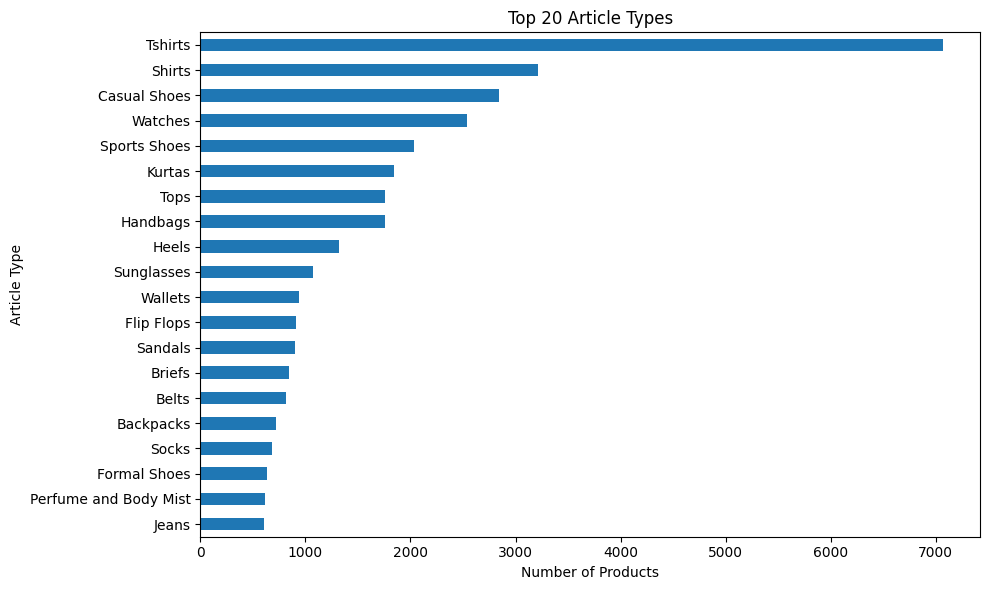

In [17]:
article_counts = df["articleType"].value_counts().head(20)

plt.figure(figsize=(10, 6))
article_counts.sort_values().plot(kind="barh")

plt.title("Top 20 Article Types")
plt.xlabel("Number of Products")
plt.ylabel("Article Type")
plt.tight_layout()
plt.show()

Some more checks:

In [18]:
article_sub = df.groupby("articleType")["subCategory"].nunique().sort_values(ascending=False)

article_sub.head(20)

articleType
Wallets                      3
Body Lotion                  2
Backpacks                    2
Shorts                       2
Travel Accessory             2
Mask and Peel                2
Belts                        2
Face Moisturisers            2
Kajal and Eyeliner           2
Face Scrub and Exfoliator    2
Flip Flops                   2
Dresses                      2
Eyeshadow                    2
Clutches                     2
Laptop Bag                   2
Scarves                      2
Ties                         2
Wristbands                   2
Swimwear                     2
Tshirts                      2
Name: subCategory, dtype: int64

In [19]:
sub_master = df.groupby("subCategory")["masterCategory"].nunique().sort_values(ascending=False)

sub_master.head(20)

subCategory
Perfumes              2
Socks                 2
Bags                  1
Apparel Set           1
Accessories           1
Belts                 1
Bottomwear            1
Cufflinks             1
Dress                 1
Eyes                  1
Eyewear               1
Bath and Body         1
Beauty Accessories    1
Fragrance             1
Flip Flops            1
Hair                  1
Free Gifts            1
Home Furnishing       1
Innerwear             1
Jewellery             1
Name: masterCategory, dtype: int64

In [20]:
print("Article types belonging to >1 subcategory:")
print(article_sub[article_sub > 1])

Article types belonging to >1 subcategory:
articleType
Wallets                      3
Body Lotion                  2
Backpacks                    2
Shorts                       2
Travel Accessory             2
Mask and Peel                2
Belts                        2
Face Moisturisers            2
Kajal and Eyeliner           2
Face Scrub and Exfoliator    2
Flip Flops                   2
Dresses                      2
Eyeshadow                    2
Clutches                     2
Laptop Bag                   2
Scarves                      2
Ties                         2
Wristbands                   2
Swimwear                     2
Tshirts                      2
Water Bottle                 2
Messenger Bag                2
Handbags                     2
Perfume and Body Mist        2
Sandals                      2
Name: subCategory, dtype: int64


In [21]:
print("Subcategories belonging to >1 master category:")
print(sub_master[sub_master > 1])

Subcategories belonging to >1 master category:
subCategory
Perfumes    2
Socks       2
Name: masterCategory, dtype: int64


In [22]:
for col in ["masterCategory", "subCategory", "articleType"]:
    print(f"\n===== {col} =====")
    print(df[col].value_counts())


===== masterCategory =====
masterCategory
Apparel           21397
Accessories       11274
Footwear           9219
Personal Care      2403
Free Items          105
Sporting Goods       25
Home                  1
Name: count, dtype: int64

===== subCategory =====
subCategory
Topwear                     15402
Shoes                        7343
Bags                         3055
Bottomwear                   2694
Watches                      2542
Innerwear                    1808
Jewellery                    1079
Eyewear                      1073
Fragrance                    1011
Sandal                        963
Wallets                       933
Flip Flops                    913
Belts                         811
Socks                         698
Lips                          527
Dress                         478
Loungewear and Nightwear      470
Saree                         427
Nails                         329
Makeup                        307
Headwear                      293
Ties        

In [23]:
print(df["baseColour"].value_counts(dropna=False))

baseColour
Black                9728
White                5538
Blue                 4918
Brown                3494
Grey                 2741
Red                  2455
Green                2115
Pink                 1860
Navy Blue            1789
Purple               1640
Silver               1090
Yellow                778
Beige                 749
Gold                  628
Maroon                581
Orange                530
Olive                 410
Multi                 394
Cream                 390
Steel                 315
Charcoal              228
Peach                 195
Off White             182
Skin                  179
Lavender              162
Grey Melange          146
Khaki                 139
Magenta               129
Teal                  120
Tan                   114
Mustard                97
Bronze                 95
Copper                 86
Turquoise Blue         69
Rust                   66
Burgundy               45
Metallic               43
Coffee Brown           31
M

In [24]:
df["productDisplayName"].str.len().describe()

count    44417.000000
mean        34.669608
std          8.520417
min          7.000000
25%         29.000000
50%         34.000000
75%         40.000000
max         88.000000
Name: productDisplayName, dtype: float64

In [25]:
df["productDisplayName"].str.split().str.len().describe()

count    44417.000000
mean         5.790868
std          1.403846
min          1.000000
25%          5.000000
50%          6.000000
75%          7.000000
max         14.000000
Name: productDisplayName, dtype: float64

In [26]:
df["productDisplayName"].sample(30, random_state=42).tolist()

['Puma Women Solid Black Jackets',
 'ADIDAS Unisex Black White Headband',
 'Murcia Women Casual Handbag',
 'Urban Yoga Women Printed Purple Kurta',
 'Nike Women As Statement White T-Shirts',
 'New Hide Men Brown Belt',
 'Nike Unisex Federer Blue Cap',
 'Park Avenue Men Grey Briefs',
 'Chromozome Men Grey Melange Trunks',
 'Bwitch Turquiose Blue Nightdress',
 'Puma Women Black Capris',
 'York Women Amazing Perfume',
 'Puma Men Faas 800 Black Sports Shoes',
 'United Colors of Benetton Women Solid Black Wallets',
 'Turtle Men Black Trousers',
 'Fogg Women Radiate Deo',
 'Nike Men Grey Striped T-shirt',
 'Lucera Women Silver Ring',
 'Gini and Jony Girls Kinky Pink Capris',
 'Lomani Women Deo',
 'Revlon Plum Deluxe Nail Enamel 315',
 'Fabindia Women Anusuya Silver Earrings',
 "Inkfruit Men's Star War Black T-shirt",
 'Aneri Women Blue Printed Kurta',
 'Puma Women White Ferrari Wallet',
 'BIBA Women Printed Green Kurta',
 'Mayhem Men Aviator Sunglasses 1024-209',
 'Lovable Women All Day Long

In [27]:
print("Unique product names:", df["productDisplayName"].nunique())
print("Duplicate product names:",
      df["productDisplayName"].duplicated().sum())

Unique product names: 31121
Duplicate product names: 13302


In [28]:
df["productDisplayName"].value_counts().head(20)

productDisplayName
Lucera Women Silver Earrings              82
Lucera Women Silver Pendant               56
Lucera Women Silver Ring                  50
Catwalk Women Black Heels                 48
Q&Q Men Black Dial Watch                  42
Fastrack Men Black Dial Watch             41
Maxima Men White Dial Watch               38
Fabindia Women Anusuya Silver Earrings    37
FNF Multi Coloured Printed Sari           32
Miami Blues Women Sunglasses              31
Coolers Men Black Sandals                 31
Murcia Women Brown Handbag                28
Murcia Women Black Handbag                28
Lucera Women Silver Pendant with Chain    28
Locomotive Men Washed Blue Jeans          27
Idee Men Black Sunglasses                 26
Mark Taylor Men Blue Striped Shirt        26
Titan Men White Dial Watch                26
Red Tape Men Brown Shoes                  26
Revv Men Steel Ring                       26
Name: count, dtype: int64

### Remarks:
